In [17]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import wasserstein_distance
from tqdm import tqdm
import pickle

In [36]:
# Set Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
SAVE_DIR = "/content/drive/MyDrive/Domain_shift/embeddings"  # Where to save .npy files
IMG_DEBUG_DIR = "/content/drive/MyDrive/Domain_shift/debug_images" # Where to save sample images to check quality
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(IMG_DEBUG_DIR, exist_ok=True)

#Dataset and Configurations set up
TARGET_NAMES = ["DOTA-bg", "DIOR-bg"]
MAX_SAMPLES = 2000
BLUR_THRESHOLD = 100.0

DATASETS_CONFIG = {
    "COCO-BG": "HichTala/coco-background",
    "DIOR-BG": "HichTala/dior-background", #target
    "DOTA-BG": "HichTala/dota-background", #target
    "DOTA": "HichTala/dota",
    "DIOR": "HichTala/dior",
    "COCO": "HichTala/coco",
    "DEEPFRUITS": "HichTala/deepfruits",
    "XVIEW": "HichTala/xview",
    "OKTOBERFEST": "HichTala/oktoberfest",
    "FASHIONPEDIA": "HichTala/fashionpedia",
    "CADOT": "HichTala/cadot",
    "ARTAXOR": "HichTala/artaxor",
    "UODD": "HichTala/uodd",
}

DATASETS_CONFIG = {
    # Target
    "DOTA-bg": {"path": "HichTala/dota-background", "blur": 20.0, "min_size": 30},
    "DIOR-bg": {"path": "HichTala/dior-background", "blur": 20.0, "min_size": 30},

    # Sources that need cleaning (Aerial crops are tiny)
    "COCO-bg": {"path": "HichTala/coco-background", "blur": 20.0, "min_size": 30},

    # Sources that are high-quality (Turn filters OFF by setting to 0)
    "DOTA": {"path": "HichTala/dota", "blur": 0.0, "min_size": 0},
    "DIOR": {"path": "HichTala/dior", "blur": 0.0, "min_size": 0},
    "COCO": {"path": "HichTala/coco", "blur": 0.0, "min_size": 0},
    "DEEPFRUITS": {"path": "HichTala/deepfruits", "blur": 0.0, "min_size": 0},
    "XVIEW":  {"path": "HichTala/xview", "blur": 0.0, "min_size": 0},
    "OKTOBERFEST":  {"path": "HichTala/oktoberfest", "blur": 0.0, "min_size": 0},
    "FASHIONPEDIA":  {"path": "HichTala/fashionpedia", "blur": 0.0, "min_size": 0},
    "CADOT":  {"path": "HichTala/cadot", "blur": 0.0, "min_size": 0},
    "ARTAXOR":  {"path": "HichTala/artaxor", "blur": 0.0, "min_size": 0},
    "UODD":  {"path": "HichTala/uodd", "blur": 0.0, "min_size": 0},
}

Using device: cuda


In [27]:
# ==============================================================================
# SECTION 3: BLUR FILTERING & EXTRACTION CLASSES
# ==============================================================================
def is_blurry(cv_img, threshold=BLUR_THRESHOLD):
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    score = cv2.Laplacian(gray, cv2.CV_64F).var()
    return score < threshold, score

# Define Transforms (Resize -> CenterCrop -> Normalize)
embed_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Update your threshold
BLUR_THRESHOLD = 20.0  # Much more forgiving now!
MIN_PIXEL_SIZE = 30    # Reject tiny, unidentifiable crops

class FilteredStreamDataset(IterableDataset):
    def __init__(self, hf_name, blur_thresh, min_size, max_samples=1000, tfms=None):
        self.ds = load_dataset(hf_name, split="train", streaming=True)
        self.ds = self.ds.shuffle(buffer_size=1000, seed=42)
        self.max_samples = max_samples
        self.tfms = tfms
        self.blur_thresh = blur_thresh
        self.min_size = min_size
        self.rejected_count = 0
        self.demo_rejected = [] # <--- FIXED: We need this to store the rejected images!

    def __iter__(self):
        count = 0
        for ex in self.ds:
            if count >= self.max_samples: break
            try:
                pil_img = ex["image"].convert("RGB")

                # 1. Size Check
                if self.min_size > 0 and (pil_img.width < self.min_size or pil_img.height < self.min_size):
                    self.rejected_count += 1
                    if len(self.demo_rejected) < 5:
                        self.demo_rejected.append((pil_img, "Too Small")) # Save why it was rejected
                    continue

                # 2. Blur Check
                if self.blur_thresh > 0:
                    cv_img = np.array(pil_img)[:, :, ::-1]
                    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
                    score = cv2.Laplacian(gray, cv2.CV_64F).var()
                    if score < self.blur_thresh:
                        self.rejected_count += 1
                        if len(self.demo_rejected) < 5:
                            self.demo_rejected.append((pil_img, f"Blurry: {score:.1f}")) # Save why it was rejected
                        continue

                # If it passes!
                tensor_img = self.tfms(pil_img) if self.tfms else pil_img
                # We yield a dummy score "OK" for accepted images
                yield tensor_img, pil_img, "OK"
                count += 1
            except Exception:
                continue

# Load Model
print("Loading ResNet50...")
base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
feature_extractor = nn.Sequential(*list(base_model.children())[:-1]).to(DEVICE)
feature_extractor.eval()

Loading ResNet50...


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [39]:
def extract_and_save(name, config):
    save_path_emb = os.path.join(SAVE_DIR, f"{name}.npy")
    save_path_img_paths = os.path.join(SAVE_DIR, f"{name}_img_paths.pkl") # New: to save image paths

    clean_imgs_dir = os.path.join(IMG_DEBUG_DIR, "all_clean_images", name)
    os.makedirs(clean_imgs_dir, exist_ok=True)

    if os.path.exists(save_path_emb) and os.path.exists(save_path_img_paths):
        print(f"✅ Found existing {name} embeddings and image paths.")
        print(f"   (Check '{clean_imgs_dir}' to see the saved images).")
        return {
            "emb": np.load(save_path_emb),
            "img_paths": pickle.load(open(save_path_img_paths, "rb"))
        }

    print(f"\n--- Extracting {name} ---")
    dataset = FilteredStreamDataset(
        hf_name=config["path"],
        blur_thresh=config["blur"],
        min_size=config["min_size"],
        max_samples=MAX_SAMPLES,
        tfms=embed_tfms
    )

    loader = DataLoader(dataset, batch_size=32, collate_fn=lambda x: (
        torch.stack([i[0] for i in x]),
        [i[1] for i in x],
        [i[2] for i in x]
    ))

    embeddings = []
    all_saved_img_paths = [] # To store paths of saved images
    image_counter = 0

    with torch.no_grad():
        for xb, pil_imgs, scores in tqdm(loader):
            # 1. Extract the math features for the classifier
            feats = feature_extractor(xb.to(DEVICE)).squeeze()
            embeddings.append(feats.cpu().numpy())

            # 2. Save EVERY SINGLE clean image to your folder
            for img, score in zip(pil_imgs, scores):
                # If the score is the text "OK" (from our class), use it, otherwise round the number
                score_str = str(score) if isinstance(score, str) else f"{score:.1f}"
                filename = f"img_{image_counter:04d}_score_{score_str}.jpg"
                current_img_path = os.path.join(clean_imgs_dir, filename)

                # Save it to the hard drive
                img.save(current_img_path)
                all_saved_img_paths.append(current_img_path)
                image_counter += 1

    full_embeddings = np.vstack(embeddings)
    print(f"  -> Clean Images Extracted: {len(full_embeddings)}")
    print(f"  -> Garbage Rejected: {dataset.rejected_count}")
    print(f"  -> 📂 SAVED ALL {len(full_embeddings)} IMAGES TO: {clean_imgs_dir}")
    np.save(save_path_emb, full_embeddings)
    pickle.dump(all_saved_img_paths, open(save_path_img_paths, "wb")) # Save image paths

    return {"emb": full_embeddings, "img_paths": all_saved_img_paths}

Fetching preview for DOTA-bg...


Resolving data files:   0%|          | 0/275 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/275 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

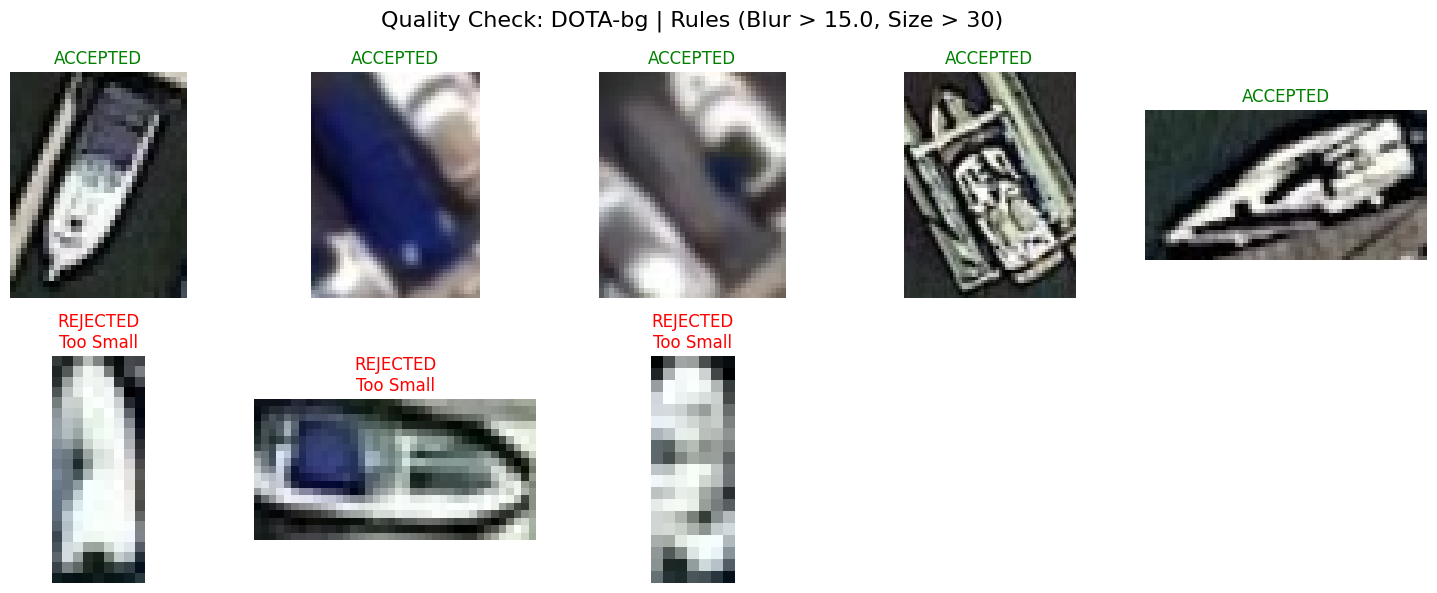

Fetching preview for DIOR-bg...


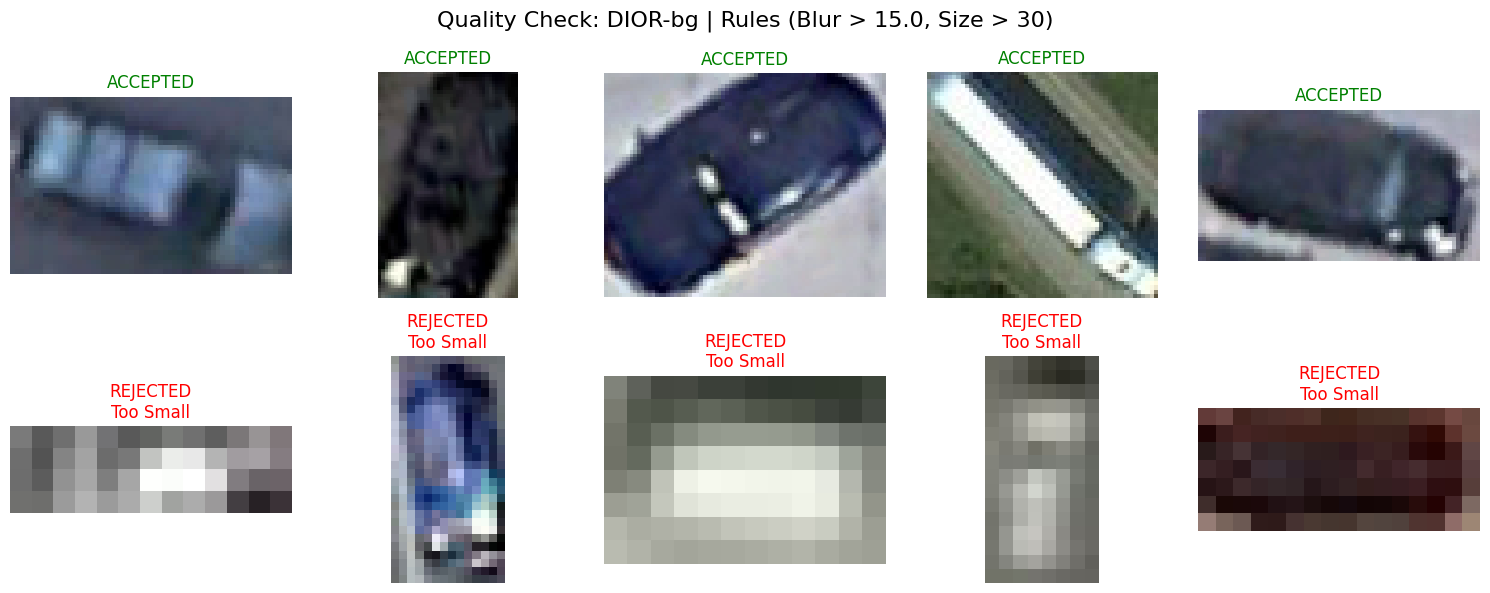

Fetching preview for COCO-bg...


Resolving data files:   0%|          | 0/103 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/103 [00:00<?, ?it/s]

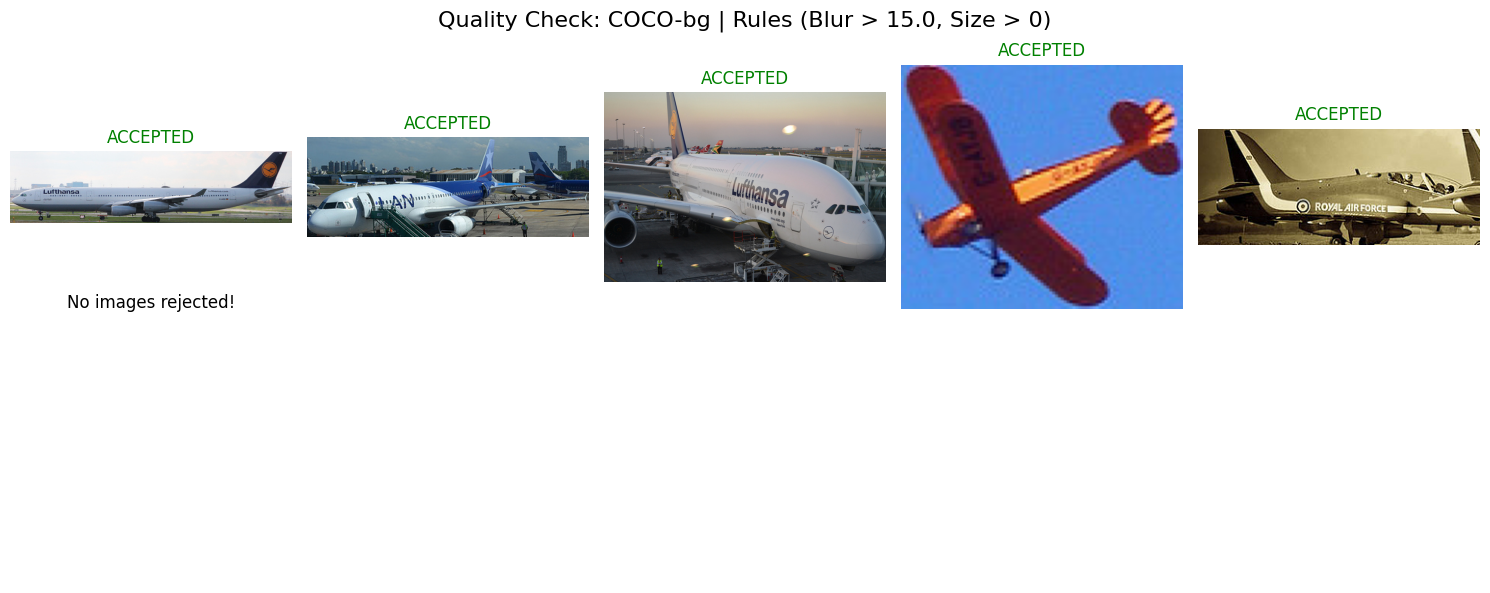

In [29]:
import matplotlib.pyplot as plt

def preview_dataset_quality(name, config):
    print(f"Fetching preview for {name}...")
    dataset = FilteredStreamDataset(
        hf_name=config["path"],
        blur_thresh=config["blur"],
        min_size=config["min_size"],
        max_samples=5, # We only need 5 good ones for the preview!
        tfms=embed_tfms
    )

    # Manually pull 5 accepted images
    saved_clean = []
    for tensor, pil_img, score in dataset:
        saved_clean.append((pil_img, score))
        if len(saved_clean) == 5:
            break

    # Get the rejected ones
    rejected_imgs = dataset.demo_rejected

    # --- PLOT THE GRID DIRECTLY IN THE NOTEBOOK ---
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f"Quality Check: {name} | Rules (Blur > {config['blur']}, Size > {config['min_size']})", fontsize=16)

    # Row 1: Clean Images
    for i in range(5):
        ax = axes[0, i]
        if i < len(saved_clean):
            img, score = saved_clean[i]
            ax.imshow(img)
            ax.set_title(f"ACCEPTED", color="green")
        ax.axis('off')

    # Row 2: Rejected Images
    for i in range(5):
        ax = axes[1, i]
        if i < len(rejected_imgs):
            img, reason = rejected_imgs[i]
            ax.imshow(img)
            ax.set_title(f"REJECTED\n{reason}", color="red")
        else:
            if i == 0: ax.set_title("No images rejected!")
        ax.axis('off')

    plt.tight_layout()
    plt.show() # <--- This guarantees it displays in your Jupyter Notebook!

# --- TEST IT IMMEDIATELY ---
# Let's test DOTA-bg and see the images instantly
preview_dataset_quality("DOTA-bg", DATASETS_CONFIG["DOTA-bg"])
preview_dataset_quality("DIOR-bg", DATASETS_CONFIG["DIOR-bg"])
preview_dataset_quality("COCO-bg", DATASETS_CONFIG["COCO-bg"])

In [30]:
# ==========================================
# 3. DISTANCE METRICS (MK-MMD & WASSERSTEIN)
# ==========================================
def single_mmd(source, target, gamma):
    K_ss = rbf_kernel(source, source, gamma=gamma)
    K_tt = rbf_kernel(target, target, gamma=gamma)
    K_st = rbf_kernel(source, target, gamma=gamma)
    np.fill_diagonal(K_ss, 0.0) # Unbiased
    np.fill_diagonal(K_tt, 0.0)
    m, n = len(source), len(target)
    mmd2 = K_ss.sum() / (m * (m - 1)) + K_tt.sum() / (n * (n - 1)) - 2.0 * K_st.mean()
    return np.sqrt(max(mmd2, 0.0))

def compute_mk_mmd(source, target, name_pair):
    # Normalize features first
    scaler = StandardScaler().fit(np.vstack([source, target]))
    s_norm = scaler.transform(source)
    t_norm = scaler.transform(target)

    gammas = np.logspace(-7, 2, 30)
    mmds = [single_mmd(s_norm, t_norm, g) for g in gammas]
    tuned_mmd = np.mean(mmds)
    print(f"{name_pair} MK-MMD: {tuned_mmd:.4f}")
    return tuned_mmd

In [31]:
def compute_wasserstein(source, target):
    pca = PCA(n_components=50, random_state=42).fit(np.vstack([source, target]))
    s_pca, t_pca = pca.transform(source), pca.transform(target)
    return np.mean([wasserstein_distance(s_pca[:,i], t_pca[:,i]) for i in range(50)])

Both Maximum Mean Discrepancy (MMD) and Wasserstein Distance (also called Earth Mover's Distance or EMD) are unsupervised metrics to measure how different two distributions are.

MMD measures whether two sets of embeddings are similar overall in kernel space.

**Conclusion: both metrics shows that "coco->dior" is close to "coco->dota and dior->dota."** DIOR harder geometrically → might need more adaptation despite being aerial.

In [32]:
def evaluate_domain_classifier(source_emb, target_emb):
    """Trains your Logistic Regression to get Acc, AUC, and Proxy A-Distance"""
    X = np.vstack([source_emb, target_emb])
    y = np.hstack([np.zeros(len(source_emb)), np.ones(len(target_emb))])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=1000).fit(scaler.fit_transform(X_train), y_train)

    probs = clf.predict_proba(scaler.transform(X_test))[:, 1]
    y_pred = clf.predict(scaler.transform(X_test))

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, probs)

    # Proxy A-Distance Formula
    err = 1 - acc
    err = min(err, 1 - err)
    pad = 2 * (1 - 2 * err)

    return acc, auc, pad

In [41]:
# ==============================================================================
# SECTION 5: MASTER EXECUTION LOOP
# ==============================================================================

# 1. EXTRACT ALL
data_store = {}
print("\n=== PHASE 1: EXTRACTION & BLUR FILTERING ===")
for name, config in DATASETS_CONFIG.items(): # Changed hf_path to config to match extract_and_save signature
    try:
        data_store[name] = extract_and_save(name, config)
    except Exception as e:
        print(f"❌ Failed to process {name}: {e}")

# 2. COMPUTE METRICS & TRAIN CLASSIFIER FOR MULTIPLE TARGETS
print(f"\n=== PHASE 2: CALCULATING DISTANCES ===")

for target_name in TARGET_NAMES:
    if target_name not in data_store:
        print(f"CRITICAL ERROR: Target {target_name} not extracted. Skipping.")
        continue

    print(f"\n" + "="*80)
    print(f"🚀 ANALYZING SOURCES FOR TARGET: {target_name}")
    print("="*80)

    target_emb_data = data_store[target_name]
    results = []

    for source_name, source_emb_data in data_store.items():
        # Don't compare a dataset to itself
        if source_name == target_name:
            continue

        print(f"  Comparing {source_name} vs {target_name}...")

        # Distance Metrics
        mmd = compute_mk_mmd(source_emb_data['emb'], target_emb_data['emb'], f"{source_name}->{target_name}") # Access 'emb'
        wd = compute_wasserstein(source_emb_data['emb'], target_emb_data['emb']) # Access 'emb'

        # Classifier Metrics
        acc, auc, pad = evaluate_domain_classifier(source_emb_data['emb'], target_emb_data['emb']) # Access 'emb'

        results.append({
            "Source Dataset": source_name,
            "MK-MMD": mmd,
            "Wasserstein": wd,
            "Classifier Acc": f"{acc*100:.1f}%",
            "AUC": auc,
            "Proxy A-Distance": pad
        })

    # 3. SHOW FINAL RESULTS FOR THIS SPECIFIC TARGET
    df_results = pd.DataFrame(results).sort_values(by="MK-MMD")
    print(f"\n🏆 RANKING REPORT FOR: {target_name} (Lowest MK-MMD is Best)")
    print(df_results.to_string(index=False))
    print("\n")


=== PHASE 1: EXTRACTION & BLUR FILTERING ===
✅ Found existing DOTA-bg embeddings and image paths.
   (Check '/content/drive/MyDrive/Domain_shift/debug_images/all_clean_images/DOTA-bg' to see the saved images).
✅ Found existing DIOR-bg embeddings and image paths.
   (Check '/content/drive/MyDrive/Domain_shift/debug_images/all_clean_images/DIOR-bg' to see the saved images).
✅ Found existing COCO-bg embeddings and image paths.
   (Check '/content/drive/MyDrive/Domain_shift/debug_images/all_clean_images/COCO-bg' to see the saved images).
✅ Found existing DOTA embeddings and image paths.
   (Check '/content/drive/MyDrive/Domain_shift/debug_images/all_clean_images/DOTA' to see the saved images).
✅ Found existing DIOR embeddings and image paths.
   (Check '/content/drive/MyDrive/Domain_shift/debug_images/all_clean_images/DIOR' to see the saved images).
✅ Found existing COCO embeddings and image paths.
   (Check '/content/drive/MyDrive/Domain_shift/debug_images/all_clean_images/COCO' to see t